# Knowledge Graph Builder - ATC Entities

Este notebook construye un grafo de conocimiento a partir de las entidades y relaciones extraídas por kex.ipynb.

## Flujo:
1. Cargar JSON de un modelo específico (compatible con page-level y sentence-level)
2. Consolidar entidades (deduplicación exacta)
3. Construir grafo con NetworkX
4. Análisis estático (centralidad, comunidades)
5. Visualización del grafo

## Compatibilidad
- **Nuevo formato**: `pagina_N.json` con `sentence_results` (lista de chunks/oraciones)
- **Formato viejo**: `pagina_N.json` con NER a nivel de página (sin `sentence_results`)

In [1]:
import json
import os
from pathlib import Path
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
from collections import defaultdict, Counter
import numpy as np
from community import community_louvain
import seaborn as sns

## Cargar datos de un modelo específico

In [2]:
def load_kex_output(output_dir, model_name="llama3"):
    """
    Carga todos los JSON de un modelo específico desde kex_output
    Soporta tanto formato viejo (page-level) como nuevo (sentence-level)
    """
    base_path = Path(output_dir)
    model_folder = None
    
    # Buscar carpeta del modelo
    for folder in base_path.iterdir():
        if folder.is_dir() and model_name in folder.name:
            model_folder = folder
            break
    
    if not model_folder:
        print(f"No se encontró carpeta para el modelo: {model_name}")
        return None
    
    print(f"Cargando datos desde: {model_folder}")
    
    all_data = []
    
    for json_file in sorted(model_folder.glob("pagina_*.json")):
        try:
            with open(json_file, 'r', encoding='utf-8') as f:
                data = json.load(f)
                data['source_file'] = json_file.name
                data['page_number'] = int(json_file.stem.split('_')[1])
                all_data.append(data)
        except Exception as e:
            print(f"Error cargando {json_file}: {e}")
    
    print(f"Cargadas {len(all_data)} páginas")
    return all_data


def load_kex_output_legacy(output_dir, model_name="llama3"):
    """
    Carga en modo legacy (solo para compatibilidad con datos antiguos)
    """
    return load_kex_output(output_dir, model_name)

In [3]:
# Cargar datos del modelo llama3
data = load_kex_output("output/4_kex_output" ,"gemma3:27b")


Cargando datos desde: output/4_kex_output/ICAO Standard Phraseology(gemma3:27b) 
Cargadas 20 páginas


## Consolidar entidades (deduplicación exacta)

In [4]:
def consolidate_entities(all_data):
    """
    Consolida entidades usando matching exacto (text.lower().strip())
    Soporta tanto formato viejo (page-level) como nuevo (sentence-level)
    """
    entity_map = {}  # normalized_text -> entity_info
    entity_sources = defaultdict(list)  # normalized_text -> list of (page, file)
    
    for page_data in all_data:
        page_num = page_data['page_number']
        source_file = page_data['source_file']
        
        # Detectar formato: sentence-level vs page-level
        if 'sentence_results' in page_data:
            # Nuevo formato: lista de chunks/oraciones
            chunks = page_data['sentence_results']
        else:
            # Formato viejo o page-level
            chunks = [page_data]  # envolver como lista para unificar procesamiento
        
        for chunk in chunks:
            ner_data = chunk.get('ner', {})
            if not isinstance(ner_data, dict) or 'entities' not in ner_data:
                continue
                
            for entity in ner_data['entities']:
                if not isinstance(entity, dict) or 'text' not in entity:
                    continue
                    
                text = entity['text']
                normalized = text.lower().strip()
                
                # Si no existe, guardar la primera aparición
                if normalized not in entity_map:
                    entity_map[normalized] = {
                        'text': text,
                        'label': entity.get('label', 'Unknown'),
                        'context': entity.get('context', ''),
                        'first_seen_page': page_num,
                        'frequency': 1
                    }
                else:
                    # Actualizar frecuencia
                    entity_map[normalized]['frequency'] += 1
                
                # Registrar fuente
                entity_sources[normalized].append((page_num, source_file))
    
    print(f"Entidades únicas consolidadas: {len(entity_map)}")
    return entity_map, entity_sources

In [5]:
# Consolidar entidades
entity_map, entity_sources = consolidate_entities(data)

# Mostrar algunas estadísticas
print("\nTop 10 entidades más frecuentes:")
for normalized, info in sorted(entity_map.items(), key=lambda x: x[1]['frequency'], reverse=True)[:10]:
    print(f"{info['text']} ({info['label']}): {info['frequency']} veces")

Entidades únicas consolidadas: 443

Top 10 entidades más frecuentes:
Big Jet 345 (Aircraft): 22 veces
AGC safety initiative (Safety Program): 19 veces
aircraft (Aircraft): 15 veces
ALL CLEAR (ATC Clearance): 12 veces
RTF (Communication System Abbreviation): 11 veces
ATC (ATC Facility): 11 veces
clearance (ATC Clearance): 8 veces
runway 27 (Runway): 8 veces
condition (Constraint): 8 veces
controller (Air Traffic Controller): 7 veces


## Construir grafo de conocimiento

In [21]:
def build_knowledge_graph(all_data, entity_map):
    """
    Construye el grafo de conocimiento usando NetworkX
    Soporta tanto formato viejo (page-level) como nuevo (sentence-level)
    """
    G = nx.DiGraph()  # Grafo dirigido
    
    # Agregar nodos (entidades)
    for normalized, entity_info in entity_map.items():
        G.add_node(
            normalized,
            entity=entity_info['text'],
            category=entity_info['label'],
            context=entity_info['context'],
            frequency=entity_info['frequency'],
            first_seen_page=entity_info['first_seen_page']
        )
    
    # Agregar aristas (relaciones)
    relationship_count = 0
    missing_entities = set()
    
    for page_data in all_data:
        page_num = page_data['page_number']
        source_file = page_data['source_file']
        
        # Detectar formato: sentence-level vs page-level
        if 'sentence_results' in page_data:
            chunks = page_data['sentence_results']
        else:
            chunks = [page_data]
        
        for chunk in chunks:
            ner_data = chunk.get('ner', {})
            if not isinstance(ner_data, dict) or 'relationships' not in ner_data:
                continue
                
            for rel in ner_data['relationships']:
                if not isinstance(rel, dict):
                    continue
                    
                subject = rel.get('subject', '')
                predicate = rel.get('predicate', '')
                obj = rel.get('object', '')
                
                if not all([subject, predicate, obj]):
                    continue
                
                # Normalizar para buscar en entity_map
                subj_norm = subject.lower().strip()
                
                if isinstance(obj, str):
                    obj_norm = obj.lower().strip()
                else:
                    obj = ",".join(obj)
                    obj_norm = obj.lower().strip()
                
                # Verificar que ambas entidades existan
                if subj_norm in entity_map and obj_norm in entity_map:
                    G.add_edge(
                        subj_norm, 
                        obj_norm, 
                        predicate=predicate,
                        source_page=page_num,
                        source_file=source_file
                    )
                    relationship_count += 1
                else:
                    # Registrar entidades faltantes
                    if subj_norm not in entity_map:
                        missing_entities.add(subject)
                    if obj_norm not in entity_map:
                        missing_entities.add(obj)
    
    print(f"Grafo construido:")
    print(f"- Nodos (entidades): {G.number_of_nodes()}")
    print(f"- Aristas (relaciones): {G.number_of_edges()}")
    print(f"- Relaciones procesadas: {relationship_count}")
    
    if missing_entities:
        print(f"\nEntidades mencionadas en relaciones pero no encontradas: {len(missing_entities)} ({len(missing_entities)*100/len(entity_map):.2f} %)")
        for entity in list(missing_entities)[:5]:  # Mostrar primeras 5
            print(f"  - {entity}")
    
    return G, missing_entities

In [22]:
# Construir el grafo
G, missing_entities = build_knowledge_graph(data, entity_map)

Grafo construido:
- Nodos (entidades): 443
- Aristas (relaciones): 423
- Relaciones procesadas: 465

Entidades mencionadas en relaciones pero no encontradas: 29 (6.55 %)
  - ensuring that flight crew members listen to all clearances
  - Aircraft Type
  - start up
  - complete
  - safe and expeditious operation of aircraft


In [12]:
for model_name in ["deepseek-r1:7b", "gemma2:9b", "gemma3:27b" , "llama3.1", "mistral:7b", "qwen2.5:7b", "qwen2.5-coder:7b", "gpt-oss:20b", "deepseek-r1:14b", "deepseek-v2:16b", "mistral:7b-instruct", "qwen2.5:14b"]:
    print( f"\n=={model_name.upper()}==\n")
    data = load_kex_output("output/4_kex_output" ,model_name)
    
    if not data:
        continue
    
    entity_map, entity_sources = consolidate_entities(data)
    G, missing_entities = build_knowledge_graph(data, entity_map)
    print("\n----------------------------------------\n")


==DEEPSEEK-R1:7B==

Cargando datos desde: output/4_kex_output/ICAO Standard Phraseology(deepseek-r1:7b) 
Cargadas 20 páginas
Entidades únicas consolidadas: 330
Grafo construido:
- Nodos (entidades): 330
- Aristas (relaciones): 192
- Relaciones procesadas: 235

Entidades mencionadas en relaciones pero no encontradas: 67 (20.30 %)
  - 120
  - Full Separation
  - 6000 feet
  - Go Around
  - Sleeping Receiver

----------------------------------------


==GEMMA2:9B==

No se encontró carpeta para el modelo: gemma2:9b

==GEMMA3:27B==

No se encontró carpeta para el modelo: gemma3:27b

==LLAMA3.1==

Cargando datos desde: output/4_kex_output/ICAO Standard Phraseology(llama3.1) 
Cargadas 20 páginas
Entidades únicas consolidadas: 357
Grafo construido:
- Nodos (entidades): 357
- Aristas (relaciones): 284
- Relaciones procesadas: 335

Entidades mencionadas en relaciones pero no encontradas: 132 (36.97 %)
  - on runway
  - left
  - Air safety improvements
  - 270 degrees ten knots
  - reason

-----

## Análisis estático del grafo

In [8]:
def analyze_graph(G):
    """
    Realiza análisis estático del grafo
    """
    stats = {}
    
    # Estadísticas básicas
    stats['nodes'] = G.number_of_nodes()
    stats['edges'] = G.number_of_edges()
    stats['density'] = nx.density(G)
    stats['is_connected'] = nx.is_weakly_connected(G)
    
    # Centralidades
    if G.number_of_nodes() > 0:
        stats['degree_centrality'] = nx.degree_centrality(G)
        stats['betweenness_centrality'] = nx.betweenness_centrality(G)
        stats['closeness_centrality'] = nx.closeness_centrality(G)
        stats['pagerank'] = nx.pagerank(G)
    
    # Componentes conectados
    weak_components = list(nx.weakly_connected_components(G))
    stats['weak_components'] = len(weak_components)
    stats['largest_component_size'] = len(max(weak_components)) if weak_components else 0
    
    return stats

In [9]:
# Analizar el grafo
stats = analyze_graph(G)

print("=== ESTADÍSTICAS DEL GRAFO ===")
print(f"Nodos: {stats['nodes']}")
print(f"Aristas: {stats['edges']}")
print(f"Densidad: {stats['density']:.4f}")
print(f"Conectado: {stats['is_connected']}")
print(f"Componentes débiles: {stats['weak_components']}")
print(f"Componente más grande: {stats['largest_component_size']} nodos")

=== ESTADÍSTICAS DEL GRAFO ===
Nodos: 443
Aristas: 423
Densidad: 0.0022
Conectado: False
Componentes débiles: 91
Componente más grande: 312 nodos


### Top entidades por centralidad

In [10]:
def show_top_entities(stats, entity_map, top_n=10):
    """
    Muestra las entidades top por diferentes métricas de centralidad
    """
    metrics = ['degree_centrality', 'betweenness_centrality', 'closeness_centrality', 'pagerank']
    
    for metric in metrics:
        if metric in stats:
            print(f"\n=== Top {top_n} por {metric.replace('_', ' ').title()} ===")
            
            # Ordenar por la métrica
            sorted_entities = sorted(
                stats[metric].items(), 
                key=lambda x: x[1], 
                reverse=True
            )[:top_n]
            
            for i, (entity_norm, score) in enumerate(sorted_entities, 1):
                entity_info = entity_map[entity_norm]
                print(f"{i:2d}. {entity_info['text']} ({entity_info['label']}) - {score:.4f}")

In [11]:
# Mostrar top entidades
show_top_entities(stats, entity_map)


=== Top 10 por Degree Centrality ===
 1. Big Jet 345 (Aircraft) - 0.1719
 2. aircraft (Aircraft) - 0.0814
 3. ATC (ATC Facility) - 0.0611
 4. condition (Constraint) - 0.0294
 5. pilots (Aircrew) - 0.0271
 6. clearance (ATC Clearance) - 0.0271
 7. flight crew (Personnel) - 0.0249
 8. controller (Air Traffic Controller) - 0.0226
 9. AGC safety initiative (Safety Program) - 0.0204
10. RTF (Communication System Abbreviation) - 0.0204

=== Top 10 por Betweenness Centrality ===
 1. aircraft (Aircraft) - 0.0282
 2. ATC (ATC Facility) - 0.0232
 3. Big Jet 345 (Aircraft) - 0.0230
 4. condition (Constraint) - 0.0155
 5. AGC safety initiative (Safety Program) - 0.0147
 6. EMERGENCY COMMUNICATIONS (ATC Procedure) - 0.0141
 7. pilots (Aircrew) - 0.0108
 8. clearance (ATC Clearance) - 0.0097
 9. RTF (Communication System Abbreviation) - 0.0084
10. Air Traffic Control (ATC Facility) - 0.0054

=== Top 10 por Closeness Centrality ===
 1. Take-off Clearance (ATC Clearance) - 0.0386
 2. Negative RVSM (R

### Distribución de tipos de entidades

In [12]:
def analyze_entity_types(entity_map):
    """
    Analiza la distribución de tipos de entidades
    """
    label_counts = Counter()
    label_freq = defaultdict(list)
    
    for entity_info in entity_map.values():
        label = entity_info['label']
        label_counts[label] += 1
        label_freq[label].append(entity_info['frequency'])
    
    # Estadísticas por tipo
    print("=== DISTRIBUCIÓN DE TIPOS DE ENTIDADES ===")
    for label, count in label_counts.most_common():
        avg_freq = np.mean(label_freq[label])
        print(f"{label}: {count} entidades (freq promedio: {avg_freq:.1f})")
    
    return label_counts

In [16]:
# Analizar tipos de entidades
label_counts = analyze_entity_types(entity_map)

=== DISTRIBUCIÓN DE TIPOS DE ENTIDADES ===
Altitude: 13 entidades (freq promedio: 1.2)
Instruction Type: 11 entidades (freq promedio: 1.0)
Document: 8 entidades (freq promedio: 1.0)
Heading: 7 entidades (freq promedio: 1.4)
Fix/Position: 7 entidades (freq promedio: 1.4)
ATC Procedure: 6 entidades (freq promedio: 1.0)
Runway: 5 entidades (freq promedio: 2.6)
Frequency: 5 entidades (freq promedio: 1.2)
Information: 4 entidades (freq promedio: 1.0)
Organization: 4 entidades (freq promedio: 1.0)
Action: 3 entidades (freq promedio: 1.3)
Aircraft: 3 entidades (freq promedio: 5.7)
Facility: 3 entidades (freq promedio: 2.7)
Aircraft Type: 3 entidades (freq promedio: 1.0)
Airspace: 2 entidades (freq promedio: 1.5)
Communication Method: 2 entidades (freq promedio: 3.5)
Safety Incident: 2 entidades (freq promedio: 1.0)
Departure Runway: 2 entidades (freq promedio: 1.5)
System Action: 2 entidades (freq promedio: 1.0)
Relative Position: 2 entidades (freq promedio: 1.0)
Distance: 2 entidades (freq p

### Tipos de relaciones (predicados)

In [13]:
def analyze_relationships(G):
    """
    Analiza los tipos de relaciones en el grafo
    """
    predicate_counts = Counter()
    
    for u, v, data in G.edges(data=True):
        predicate = data.get('predicate', 'Unknown')
        predicate_counts[predicate] += 1
    
    print("=== TIPOS DE RELACIONES ===")
    for predicate, count in predicate_counts.most_common():
        print(f"{predicate}: {count} relaciones")
    
    return predicate_counts

In [14]:
# Analizar relaciones
predicate_counts = analyze_relationships(G)

=== TIPOS DE RELACIONES ===
includes: 20 relaciones
requires: 14 relaciones
uses: 10 relaciones
relates to: 9 relaciones
follows: 7 relaciones
applies to: 7 relaciones
reports: 6 relaciones
issues: 6 relaciones
instructs: 6 relaciones
is at: 5 relaciones
provides: 5 relaciones
must contain: 5 relaciones
related to: 4 relaciones
caused by: 4 relaciones
references: 4 relaciones
has: 4 relaciones
requests: 4 relaciones
must be seen by: 4 relaciones
assigns: 4 relaciones
must be: 4 relaciones
contributes to: 4 relaciones
flies: 3 relaciones
communicates with: 3 relaciones
precedes: 3 relaciones
is instructed to: 3 relaciones
contact: 3 relaciones
taxi to: 3 relaciones
associated with: 3 relaciones
manages: 3 relaciones
imposes: 3 relaciones
is: 3 relaciones
can be confused with: 3 relaciones
confused with: 3 relaciones
impacts: 3 relaciones
issued by: 3 relaciones
must be read back in full using: 3 relaciones
defines: 2 relaciones
addresses: 2 relaciones
occurs in: 2 relaciones
is causal f

### Detección de comunidades

In [15]:
def detect_communities(G):
    """
    Detecta comunidades usando el algoritmo de Louvain
    """
    # Convertir a grafo no dirigido para detección de comunidades
    G_undirected = G.to_undirected()
    
    # Detectar comunidades
    communities = community_louvain.best_partition(G_undirected)
    
    # Estadísticas de comunidades
    community_sizes = Counter(communities.values())
    
    print(f"=== COMUNIDADES DETECTADAS ===")
    print(f"Número de comunidades: {len(community_sizes)}")
    
    for comm_id, size in community_sizes.most_common():
        print(f"Comunidad {comm_id}: {size} nodos")
    
    return communities, community_sizes

In [16]:
# Detectar comunidades
communities, community_sizes = detect_communities(G)

=== COMUNIDADES DETECTADAS ===
Número de comunidades: 106
Comunidad 10: 67 nodos
Comunidad 2: 32 nodos
Comunidad 1: 28 nodos
Comunidad 8: 27 nodos
Comunidad 46: 25 nodos
Comunidad 21: 25 nodos
Comunidad 12: 22 nodos
Comunidad 13: 14 nodos
Comunidad 19: 14 nodos
Comunidad 15: 13 nodos
Comunidad 18: 10 nodos
Comunidad 82: 10 nodos
Comunidad 60: 9 nodos
Comunidad 11: 6 nodos
Comunidad 50: 6 nodos
Comunidad 71: 6 nodos
Comunidad 17: 4 nodos
Comunidad 32: 4 nodos
Comunidad 51: 4 nodos
Comunidad 56: 4 nodos
Comunidad 57: 4 nodos
Comunidad 91: 4 nodos
Comunidad 92: 4 nodos
Comunidad 94: 3 nodos
Comunidad 36: 2 nodos
Comunidad 40: 2 nodos
Comunidad 41: 2 nodos
Comunidad 42: 2 nodos
Comunidad 48: 2 nodos
Comunidad 54: 2 nodos
Comunidad 55: 2 nodos
Comunidad 58: 2 nodos
Comunidad 59: 2 nodos
Comunidad 61: 2 nodos
Comunidad 83: 2 nodos
Comunidad 90: 2 nodos
Comunidad 96: 2 nodos
Comunidad 98: 2 nodos
Comunidad 3: 2 nodos
Comunidad 16: 2 nodos
Comunidad 14: 1 nodos
Comunidad 22: 1 nodos
Comunidad 

## Visualización del grafo

In [17]:
def visualize_graph(G, entity_map, communities=None, layout='spring', figsize=(15, 10)):
    """
    Visualiza el grafo con matplotlib
    """
    plt.figure(figsize=figsize)
    
    # Layout
    if layout == 'spring':
        pos = nx.spring_layout(G, k=3, iterations=50)
    elif layout == 'circular':
        pos = nx.circular_layout(G)
    else:
        pos = nx.random_layout(G)
    
    # Colores por tipo de entidad
    label_colors = {}
    unique_labels = list(set(entity_map[node]['label'] for node in G.nodes()))
    colors = plt.cm.Set3(np.linspace(0, 1, len(unique_labels)))
    
    for i, label in enumerate(unique_labels):
        label_colors[label] = colors[i]
    
    node_colors = [label_colors[entity_map[node]['label']] for node in G.nodes()]
    
    # Tamaño de nodos por centralidad de grado
    degrees = dict(G.degree())
    node_sizes = [degrees[node] * 100 + 200 for node in G.nodes()]
    
    # Dibujar grafo
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.7)
    nx.draw_networkx_edges(G, pos, alpha=0.3, arrows=True, arrowsize=20)
    
    # Etiquetas solo para nodos importantes
    important_nodes = [node for node, degree in degrees.items() if degree > np.percentile(list(degrees.values()), 75)]
    labels = {node: entity_map[node]['text'] for node in important_nodes}
    nx.draw_networkx_labels(G, pos, labels, font_size=8)
    
    # Leyenda
    legend_elements = [plt.Line2D([0], [0], marker='o', color='w', 
                               markerfacecolor=label_colors[label], markersize=10, label=label)
                      for label in unique_labels]
    plt.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.15, 1))
    
    plt.title(f"Grafo de Conocimiento ATC\n{G.number_of_nodes()} nodos, {G.number_of_edges()} aristas")
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    return pos

/tmp/ipykernel_24877/1379986804.py:46: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


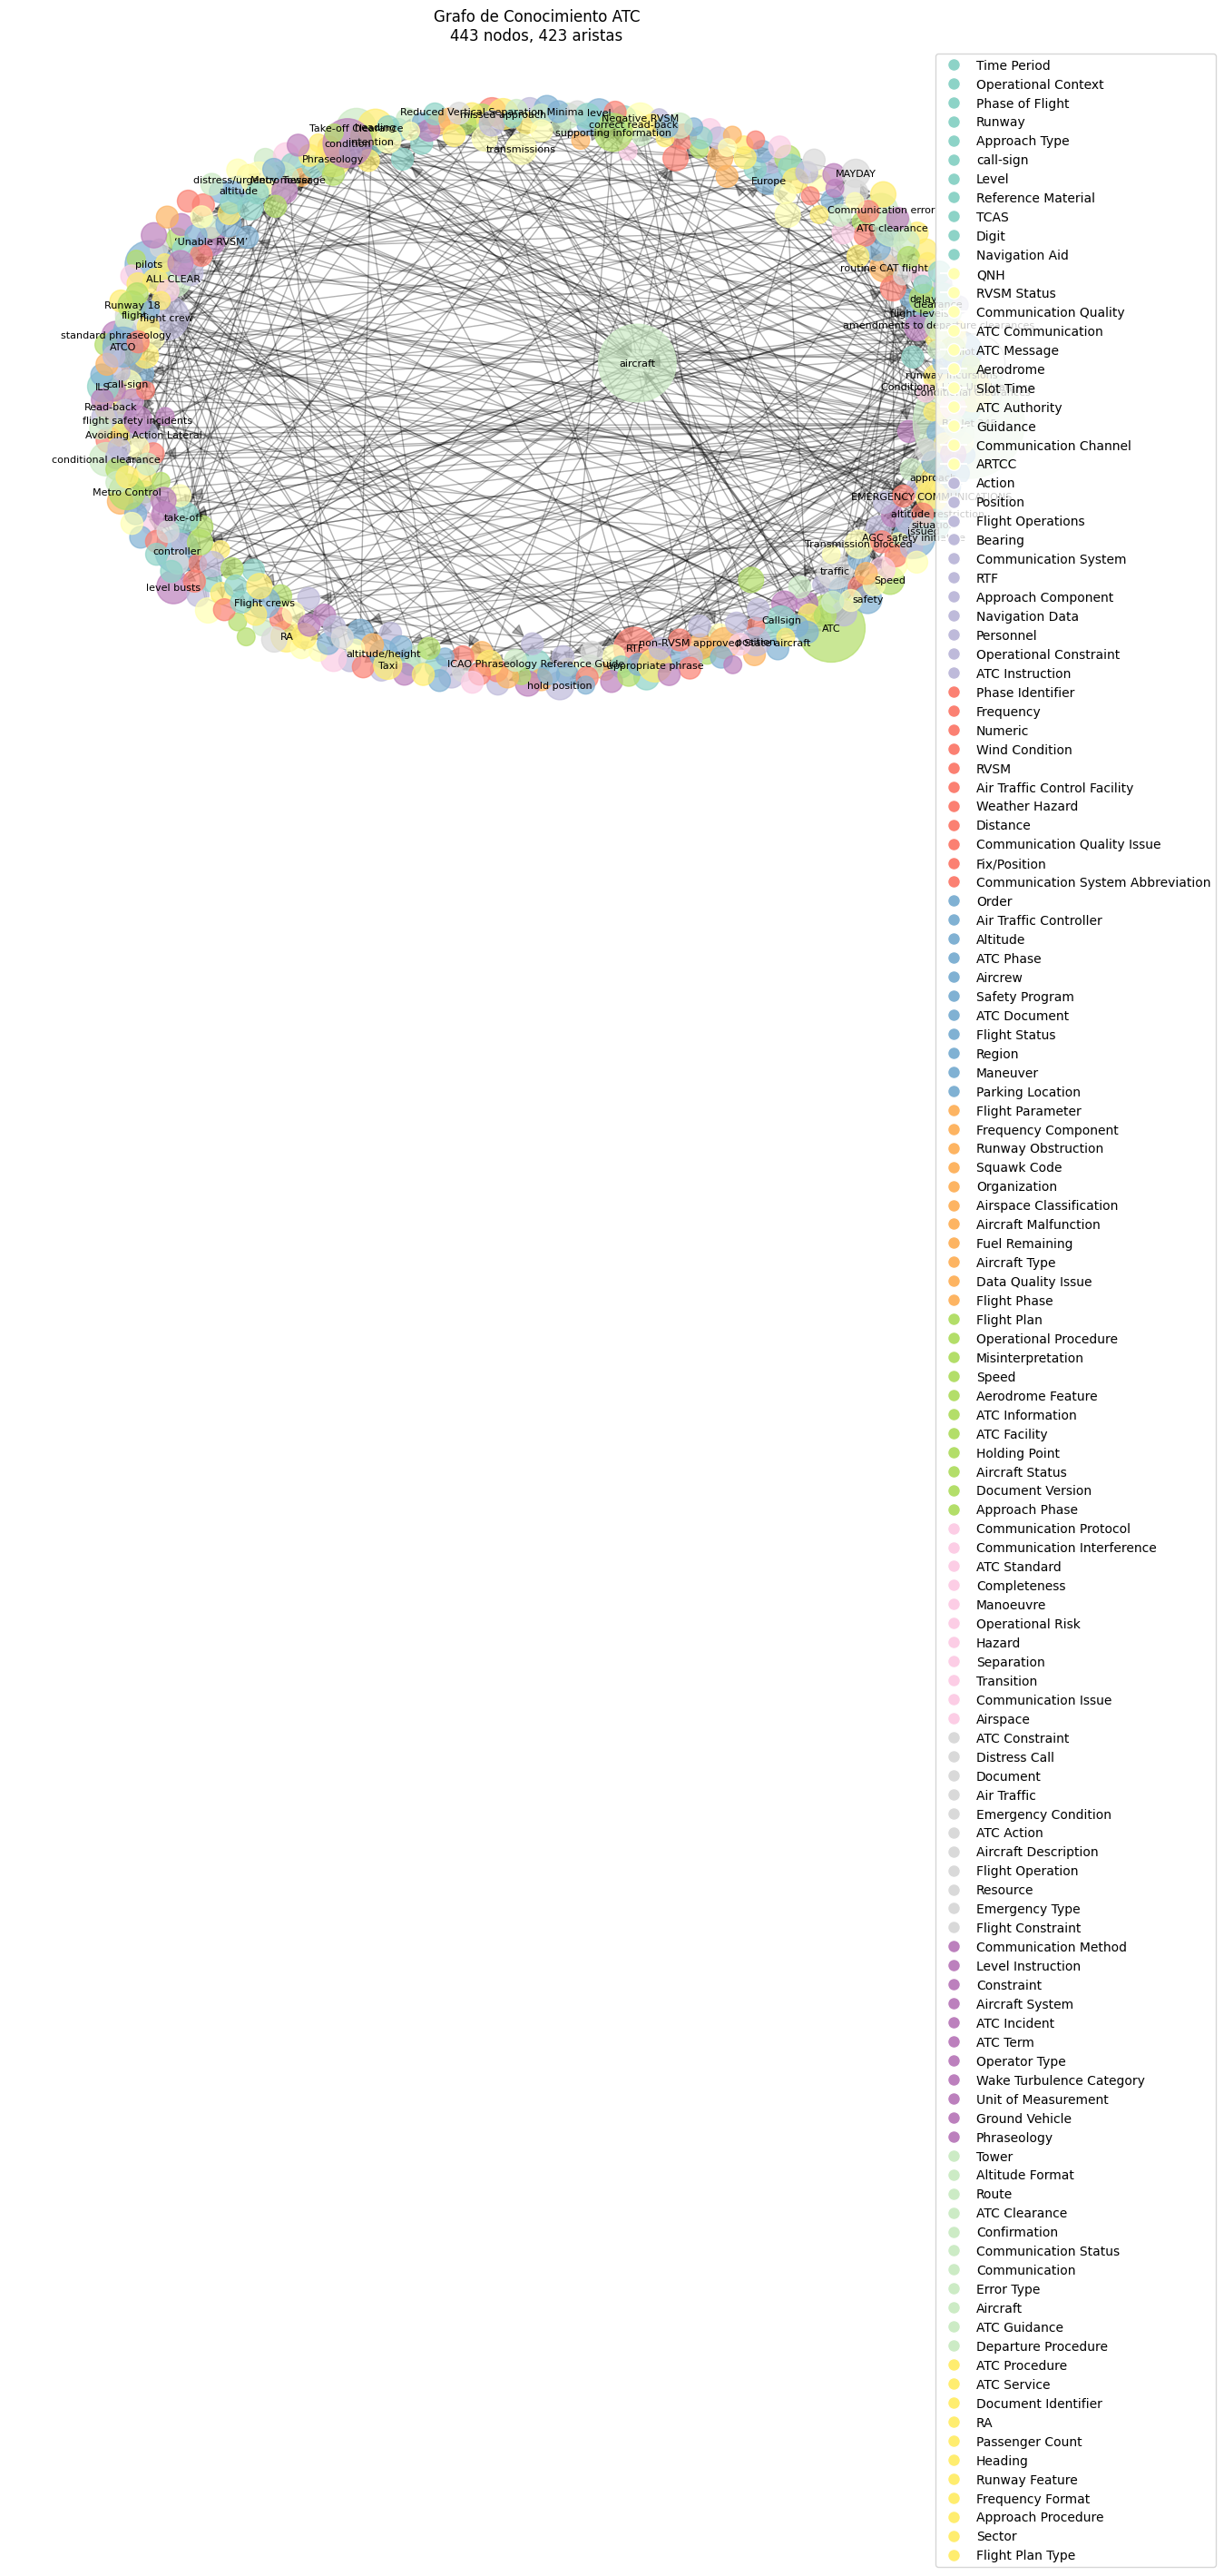

In [18]:
# Visualizar el grafo
pos = visualize_graph(G, entity_map, communities)

## Exportar grafo

In [26]:
def export_graph(G, entity_map, output_dir="graph_output", model_name="llama3"):
    """
    Exporta el grafo en múltiples formatos
    """
    # Crear directorio de salida
    output_path = Path(output_dir)
    output_path.mkdir(exist_ok=True)
    
    base_filename = f"atc_kg_{model_name}"
    
    # 1. Exportar como GraphML (para NetworkX)
    graphml_file = output_path / f"{base_filename}.graphml"
    nx.write_graphml(G, graphml_file)
    print(f"Guardado GraphML: {graphml_file}")
    
    # 2. Exportar como JSON (custom format)
    json_data = {
        'metadata': {
            'model': model_name,
            'nodes': G.number_of_nodes(),
            'edges': G.number_of_edges(),
            'created_at': pd.Timestamp.now().isoformat()
        },
        'nodes': [],
        'edges': []
    }
    
    # Agregar nodos
    for node in G.nodes():
        node_data = G.nodes[node]
        json_data['nodes'].append({
            'id': node,
            'entity': node_data['entity'],
            'category': node_data['category'],
            'context': node_data['context'],
            'frequency': node_data['frequency'],
            'first_seen_page': node_data['first_seen_page']
        })
    
    # Agregar aristas
    for u, v, data in G.edges(data=True):
        json_data['edges'].append({
            'source': u,
            'target': v,
            'predicate': data['predicate'],
            'source_page': data['source_page'],
            'source_file': data['source_file']
        })
    
    json_file = output_path / f"{base_filename}.json"
    with open(json_file, 'w', encoding='utf-8') as f:
        json.dump(json_data, f, indent=2, ensure_ascii=False)
    print(f"Guardado JSON: {json_file}")
    
    # 3. Exportar nodos como CSV
    nodes_df = pd.DataFrame([{
        'id': node,
        'entity': G.nodes[node]['entity'],
        'category': G.nodes[node]['category'],
        'context': G.nodes[node]['context'],
        'frequency': G.nodes[node]['frequency'],
        'first_seen_page': G.nodes[node]['first_seen_page']
    } for node in G.nodes()])
    
    nodes_csv = output_path / f"{base_filename}_nodes.csv"
    nodes_df.to_csv(nodes_csv, index=False, encoding='utf-8')
    print(f"Guardado CSV nodos: {nodes_csv}")
    
    # 4. Exportar aristas como CSV
    edges_df = pd.DataFrame([{
        'source': u,
        'target': v,
        'predicate': data['predicate'],
        'source_page': data['source_page'],
        'source_file': data['source_file']
    } for u, v, data in G.edges(data=True)])
    
    edges_csv = output_path / f"{base_filename}_edges.csv"
    edges_df.to_csv(edges_csv, index=False, encoding='utf-8')
    print(f"Guardado CSV aristas: {edges_csv}")
    
    return output_path

In [27]:
# Exportar el grafo
export_path = export_graph(G, entity_map, output_dir="output/graph_output", model_name="gemma2:9b")

Guardado GraphML: output/graph_output/atc_kg_gemma2:9b.graphml
Guardado JSON: output/graph_output/atc_kg_gemma2:9b.json
Guardado CSV nodos: output/graph_output/atc_kg_gemma2:9b_nodes.csv
Guardado CSV aristas: output/graph_output/atc_kg_gemma2:9b_edges.csv
